# Сравнение линейной, квадратичной и степенной моделей

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# данные openintro cpu, срез по intel
df = pd.read_csv('data/cpu.csv')
x = df['threads'].values.astype(float)
y = df['tdp'].values.astype(float)
n = len(df)
df.describe().round(2)

,threads,tdp
count,60.00,60.00
mean,21.00,72.87
std,56.97,76.89
min,1.00,2.00
25%,3.50,35.00
50%,4.00,52.50
75%,12.00,80.00
max,288.00,380.00


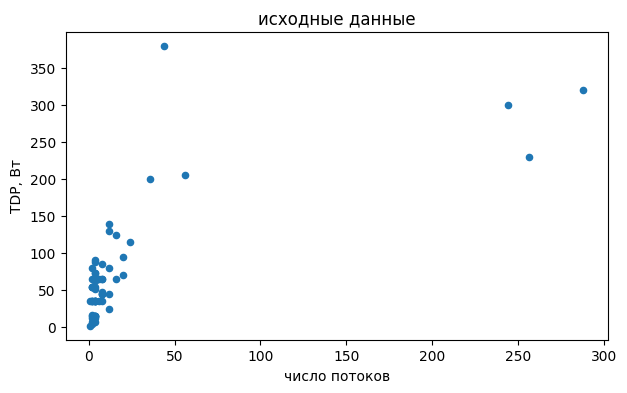

In [2]:
plt.figure(figsize=(7, 4))
plt.scatter(x, y, s=20)
plt.xlabel('число потоков')
plt.ylabel('TDP, Вт')
plt.title('исходные данные')
plt.show()

In [3]:
sxx = ((x - x.mean()) ** 2).sum()
sxy = ((x - x.mean()) * (y - y.mean())).sum()
tss = ((y - y.mean()) ** 2).sum()

b = sxy / sxx
a = y.mean() - b * x.mean()
lin = a + b * x

print('Sxx', round(sxx, 1), 'Sxy', round(sxy, 1), 'TSS', round(tss, 4))
print('линейная: y =', round(a, 4), '+', round(b, 6), '* x')

Sxx 191474.0 Sxy 190239.0 TSS 348822.9333
линейная: y = 52.0021 + 0.99355 * x


In [4]:
k = np.polyfit(x, y, 2)
kv = np.polyval(k, x)

print('квадратичная: y =', round(k[2], 4), '+', round(k[1], 4), '* x', round(k[0], 6), '* x^2')
print('вершина параболы на x =', round(-k[1] / (2 * k[0]), 1))

квадратичная: y = 25.0859 + 4.6524 * x -0.013743 * x^2
вершина параболы на x = 169.3


In [5]:
u = np.log(x)
v = np.log(y)
bp = ((u - u.mean()) * (v - v.mean())).sum() / ((u - u.mean()) ** 2).sum()
ap = np.exp(v.mean() - bp * u.mean())
st = ap * x ** bp

print('степенная: y =', round(ap, 4), '* x ^', round(bp, 6))

степенная: y = 15.6714 * x ^ 0.587528


In [6]:
rows = []
for name, p in [('линейная', lin), ('квадратичная', kv), ('степенная', st)]:
    rss = ((y - p) ** 2).sum()
    rows.append([name, round(rss, 2), round(1 - rss / tss, 4),
                 round(np.sqrt(rss / n), 2), round(100 / n * np.abs((y - p) / y).sum(), 2)])

pd.DataFrame(rows, columns=['model', 'RSS', 'R2', 'RMSE', 'A'])

,model,RSS,R2,RMSE,A
0,линейная,159810.97,0.5419,51.61,152.54
1,квадратичная,89374.47,0.7438,38.60,102.51
2,степенная,156496.66,0.5514,51.07,75.65


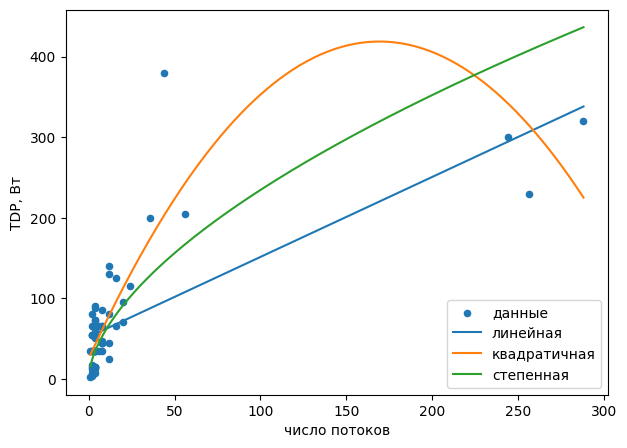

In [7]:
xs = np.linspace(1, x.max(), 300)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=20, label='данные')
plt.plot(xs, a + b * xs, label='линейная')
plt.plot(xs, np.polyval(k, xs), label='квадратичная')
plt.plot(xs, ap * xs ** bp, label='степенная')
plt.xlabel('число потоков')
plt.ylabel('TDP, Вт')
plt.legend()
plt.show()

In [8]:
rss = ((y - lin) ** 2).sum()
s = np.sqrt(rss / (n - 2))
se_b = s / np.sqrt(sxx)
se_a = s * np.sqrt(1 / n + x.mean() ** 2 / sxx)
tkr = stats.t.ppf(0.975, n - 2)
tn = b / se_b

print('s =', round(s, 4), '  SE(a) =', round(se_a, 6), '  SE(b) =', round(se_b, 6))
print('ди для a', round(a - tkr * se_a, 4), round(a + tkr * se_a, 4))
print('ди для b', round(b - tkr * se_b, 4), round(b + tkr * se_b, 4))
print('t набл', round(tn, 4), '  p', 2 * stats.t.sf(abs(tn), n - 2))

s = 52.4915   SE(a) = 7.229716   SE(b) = 0.119959
ди для a 37.5303 66.474
ди для b 0.7534 1.2337
t набл 8.2824   p 2.0631557146599877e-11


In [9]:
x0 = 1.06 * x.mean()

print('точка прогноза', round(x0, 2))
print('линейная', round(a + b * x0, 2))
print('квадратичная', round(np.polyval(k, x0), 2))
print('степенная', round(ap * x0 ** bp, 2))

точка прогноза 22.26
линейная 74.12
квадратичная 121.84
степенная 97.01


По R2 и RMSE лучше квадратичная, 0.744 против 0.54 и 0.55 у остальных, прогноз при x0 = 22.26 около 122 Вт.

Но экстраполировать ее нельзя - вершина на x ~ 169, дальше модель разворачивается вниз.

Степенная проигрывает по R2, зато ведет себя адекватнее на малых x, относительная ошибка вдвое меньше